**Global Tourism & Travel Trends Analytics**





**Selected the topic:**


The selected topic was:

Global Tourism & Travel Trends Analytics: Visitor Behaviour, Spending and Sustainability

This topic was chosen because it supports several useful areas of analysis:

Tourist spending
Travel purpose
Destination popularity
Trip duration
Booking behaviour
Satisfaction
Recommendation intention
Environmental impact

**Project Introduction:**

This project studies 10,000 tourism records across 2019–2024. It examines visitor profiles, travel choices, trip duration, spending, satisfaction, recommendation intention, and carbon footprint.

Data source note: Kaggle identifies this dataset as synthetically generated. The findings below are useful for demonstrating data-analysis methods and business reasoning, but they should not be interpreted as official tourism statistics.



**Project objectives:**

1.   Load and audit a wide tourism dataset.
2.   Clean missing values, data types, and duplicate records.
3.   Create useful business metrics such as spending per traveler and spending per night.
4.   Use descriptive and inferential statistics to test relationships.
5. Produce more than 10 visualizations with written explanations.
6. Translate the analysis into practical tourism-business recommendations.

**Selected and verified the dataset**

The dataset was obtained from Kaggle:

Global Tourism & Travel Trends Dataset (2019–2024)

I checked the dataset before using it:

1. Rows: 10,000
2. Original columns: 33
3. Numerical columns: 11
4. Categorical/text columns: 22
5. Missing cells: 5,948
6. Duplicate rows: 0
7. The dataset comfortably satisfies the minimum requirement of 500 records and 10 columns.

One important limitation is that Kaggle describes it as a synthetically generated dataset. Therefore, the project demonstrates analysis techniques, but its results should not be presented as official tourism statistics.

**5. Defined the analytical questions**

The analysis was designed to answer four main questions:

1. How does tourist spending vary by travel purpose, traveler type, destination, and accommodation?
2. Are longer trips associated with higher total spending?
3. How are satisfaction and recommendation intention related?
4. Which travel choices have lower carbon footprints?

These questions gave the notebook a clear purpose instead of producing unrelated charts.

**6. Loaded the dataset**

I used Pandas to load the CSV:

In [ ]:
import pandas as pd
from google.colab import files

# Upload the CSV file
uploaded = files.upload()

# Get the exact filename
file_name = next(iter(uploaded))

# Load the original dataset
df_raw = pd.read_csv(file_name)

print("Original dataset loaded successfully!")
print("File name:", file_name)
print("Dataset shape:", df_raw.shape)

Saving global_tourism_travel_trends.csv to global_tourism_travel_trends.csv
Original dataset loaded successfully!
File name: global_tourism_travel_trends.csv
Dataset shape: (10000, 33)


This opens a window where you select the CSV file from your computer.After selecting the file **global_tourism_travel_trends.csv**

**1. Data cleaning and preparation**

The raw file has missing values in several survey-style categorical fields. The cleaning strategy is deliberately simple and auditable:

- Remove accidental whitespace from text values.
- Convert numeric-looking columns to numeric types.
- Replace missing categorical values with `Unknown`.
- Replace missing numerical values with the median of that column.
- Remove exact duplicate rows, if any.

The purpose of preprocessing is to prepare the original data for analysis. I performed the following steps:

a. Created a copy of the original data.

b. Checked missing values.

c. Cleaned text formatting.

d. Filled missing values.

e. Checked and removed duplicates.

f. Created new calculated columns.

g. Checked the final cleaned data.

**a. Created a copy of the original data.**

In [ ]:
# Create a working copy for cleaning
df = df_raw.copy()

print("Working copy created successfully!")
print("Dataset shape:", df.shape)

Working copy created successfully!
Dataset shape: (10000, 33)


**b. Check missing values and duplicates**


In [ ]:
print("Missing values before cleaning:")
print(df.isna().sum().sum())

Missing values before cleaning:
5948


In [ ]:
print("Duplicate rows before cleaning:")
print(df.duplicated().sum())

Duplicate rows before cleaning:
0


This means:
*   The dataset has 5,948 empty cells.
*   The dataset has no duplicate rows.
*   The missing values still need to be handled.

**c. Cleaned text formatting.**

In [ ]:
# Separate numerical and categorical columns

numeric_columns = df.select_dtypes(
    include="number"
).columns.tolist()

categorical_columns = df.select_dtypes(
    exclude="number"
).columns.tolist()

print("Number of numerical columns:", len(numeric_columns))
print("Number of categorical columns:", len(categorical_columns))

print("\nNumerical columns:")
print(numeric_columns)

print("\nCategorical columns:")
print(categorical_columns)

Number of numerical columns: 11
Number of categorical columns: 22

Numerical columns:
['year', 'month', 'num_travelers', 'duration_nights', 'advance_booking_days', 'budget_per_person_usd', 'total_trip_spend_usd', 'restaurant_spend_per_day_usd', 'attractions_visited', 'trip_rating', 'carbon_footprint_kg_co2']

Categorical columns:
['trip_id', 'season', 'origin_country', 'destination_country', 'travel_purpose', 'traveler_type', 'transport_mode', 'accommodation_type', 'visa_type', 'booking_channel', 'local_transport_used', 'travel_insurance', 'repeat_visitor', 'overall_satisfaction', 'safety_perception', 'language_barrier', 'wifi_satisfaction', 'would_recommend', 'social_media_shared', 'eco_friendly_choices', 'currency_satisfaction', 'health_safety_compliance']


**What this code does**

It separates the dataset into:

* Numerical columns: columns containing numbers
* Categorical columns: columns containing text or categories

We need to separate them because we will clean them differently:

* Missing text values will become Unknown.
* Missing numerical values will be replaced with the median.

Next step: Clean the text columns


**d. Filled missing values.**

In [ ]:
# Remove extra spaces from text columns

for column in categorical_columns:
    df[column] = (
        df[column]
        .astype("string")
        .str.strip()
    )

print("Text formatting completed.")

Text formatting completed.


Purpose

This removes unnecessary spaces from values such as:

" Hotel"

"Hotel "

so they are treated as the same category:

"Hotel"

**e. Checked and removed duplicates.**

Next step: Fill missing categorical values

In [ ]:
# Replace missing text values with "Unknown"

for column in categorical_columns:
    df[column] = df[column].fillna("Unknown")

print("Missing categorical values have been filled.")

Missing categorical values have been filled.


Purpose:
A missing text value is replaced with: Unknown

We use Unknown instead of guessing the correct category.

**f. Created new calculated columns.**

Next step: Fill missing numerical values


In [ ]:
# Replace missing numerical values with the median

for column in numeric_columns:
    df[column] = df[column].fillna(
        df[column].median()
    )

print("Missing numerical values have been filled.")

Missing numerical values have been filled.


Purpose

Each missing numerical value is replaced with the median value of that column.

For example, if a spending value is missing, it will be replaced with the typical middle spending value.

**g. Checked the final cleaned data.**

Check whether the cleaning worked

In [ ]:
print("Missing values after cleaning:")
print(df.isna().sum().sum())

print("Duplicate rows after cleaning:")
print(df.duplicated().sum())

Missing values after cleaning:
0
Duplicate rows after cleaning:
0


That confirms that:

All missing values were handled.
There are still no duplicate rows.

**Creating Derived Features**

Derived features are new columns created from existing columns.

These features help provide additional information about travel spending, budget, trip duration, and visitor recommendations.

a. Total Budget

In [ ]:
df["total_budget_usd"] = (
    df["budget_per_person_usd"]
    * df["num_travelers"]
)

This calculates the total planned budget for the entire group.
Formuls:Total Budget = Budget per Person × Number of Travelers

b. Spending per Traveler


In [ ]:
df["total_spend_per_traveler_usd"] = (
    df["total_trip_spend_usd"]
    / df["num_travelers"]
)

Explanation
This calculates the average spending for one traveler.

This is useful because a group with five travelers will normally spend more than one traveler.

c. Spending per Night per Traveler

In [ ]:
df["spend_per_night_per_traveler_usd"] = (
    df["total_trip_spend_usd"]
    / df["num_travelers"]
    / df["duration_nights"]
)

This calculates the average spending for one traveler during one night.



d. Budget Variance

In [ ]:
df["budget_variance_usd"] = (
    df["total_trip_spend_usd"]
    - df["total_budget_usd"]
)

This compares actual spending with planned spending.
* Positive value means the traveler spent more than planned.
* Negative value means the traveler spent less than planned.

e. Month Name

In [ ]:
months = {
    1: "January",
    2: "February",
    3: "March",
    4: "April",
    5: "May",
    6: "June",
    7: "July",
    8: "August",
    9: "September",
    10: "October",
    11: "November",
    12: "December"
}

df["month_name"] = df["month"].map(months)

The original dataset contains the month as a number.
For example: 7 is changed to: July

This makes the results easier to understand.

f. Quarter

In [ ]:
df["quarter"] = (
    "Q"
    + (((df["month"] - 1) // 3) + 1).astype(str)
)

This groups the months into four quarters:

January to March   → Q1

April to June      → Q2

July to September  → Q3

October to December → Q4

g. Recommendation Flag

In [ ]:
# Convert recommendation answers into numbers

df["recommendation_flag"] = df["would_recommend"].map({
    "Yes": 1,
    "No": 0
})

print("Recommendation flag created successfully.")

Recommendation flag created successfully.


This code converts the would_recommend values into numbers.
Yes becomes 1 and No becomes 0, making it easier to calculate the recommendation percentage.

h. High-Value Trip

In [ ]:
median_spend = df["total_spend_per_traveler_usd"].median()

df["high_value_trip"] = (
    df["total_spend_per_traveler_usd"] >= median_spend
).astype(int)

This compares each trip’s spending with the median spending.
Trips at or above the median are marked 1, and the remaining trips are marked 0.

**Last Data Quality Check**

After cleaning and creating new columns, the dataset is checked again with following checks are performed: Missing values, Duplicate records, Dataset size, Data types, First five rows of the cleaned dataset


In [ ]:
print("Missing values:")
print(df.isnull().sum().sum())

print("\nDuplicate records:")
print(df.duplicated().sum())

print("\nDataset shape:")
print(df.shape)

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 rows of cleaned dataset:")
display(df.head())

Missing values:
10000

Duplicate records:
0

Dataset shape:
(10000, 41)

Data types:
trip_id                             string[python]
year                                         int64
month                                        int64
season                              string[python]
origin_country                      string[python]
destination_country                 string[python]
travel_purpose                      string[python]
traveler_type                       string[python]
num_travelers                                int64
duration_nights                              int64
transport_mode                      string[python]
accommodation_type                  string[python]
visa_type                           string[python]
booking_channel                     string[python]
advance_booking_days                         int64
budget_per_person_usd                      float64
total_trip_spend_usd                       float64
restaurant_spend_per_day_usd               float

,trip_id,year,month,season,origin_country,destination_country,travel_purpose,traveler_type,num_travelers,duration_nights,...,currency_satisfaction,health_safety_compliance,total_budget_usd,total_spend_per_traveler_usd,spend_per_night_per_traveler_usd,budget_variance_usd,month_name,quarter,recommendation_flag,high_value_trip
0,TRP0000001,2022,4,Autumn (Sep-Nov),China,USA,Business,Couple,2,6,...,Unfavorable,Unknown,5643.60,2821.80,470.300000,0.0,April,Q2,NaN,1
1,TRP0000002,2024,7,Spring (Mar-May),South Korea,Spain,Leisure/Tourism,Family,4,6,...,Very Unfavorable,Unknown,19001.68,4750.42,791.736667,0.0,July,Q3,NaN,1
2,TRP0000003,2022,9,Winter (Dec-Feb),Pakistan,USA,Leisure/Tourism,Group Tour,24,14,...,Neutral,Full,43763.76,1823.49,130.249286,0.0,September,Q3,NaN,1
3,TRP0000004,2019,7,Summer (Jun-Aug),Italy,Egypt,Leisure/Tourism,Solo,1,17,...,Unfavorable,Full,4474.59,4474.59,263.211176,0.0,July,Q3,NaN,1
4,TRP0000005,2024,12,Spring (Mar-May),USA,New Zealand,Adventure/Sports,Solo,1,16,...,Neutral,Full,2546.87,2546.87,159.179375,0.0,December,Q4,NaN,1


## **TASK #3**

## 3. Exploratory Data Analysis and Visualizations

Exploratory Data Analysis is performed to understand the patterns and relationships in the tourism dataset.

Matplotlib and Seaborn are used to create the visualizations.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

Explanation: Matplotlib and Seaborn are Python libraries used to create charts and visualizations.

### Visualization 1: Records by year
 3.1 Number of Tourism Records by Year

This chart shows the number of tourism records available for each year.


Saving global_tourism_travel_trends[1].csv to global_tourism_travel_trends[1].csv
Dataset loaded successfully!
Dataset shape: (10000, 33)


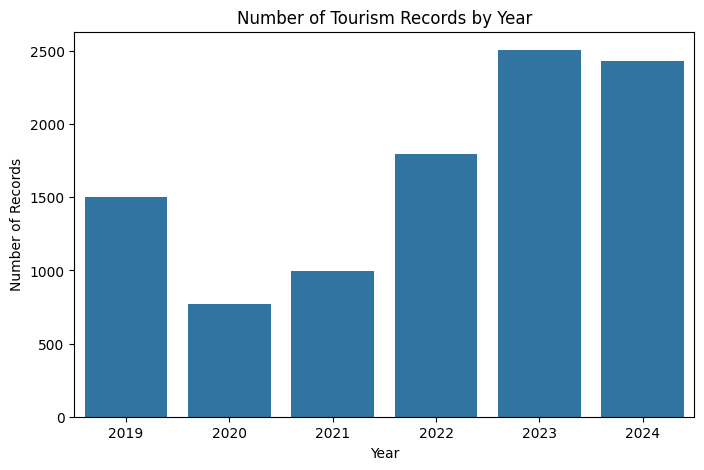

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

# Upload the dataset
uploaded = files.upload()

# Get the actual uploaded filename
file_name = list(uploaded.keys())[0]

# Load the dataset
df = pd.read_csv(file_name)

# Check that the dataset loaded
print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

# Create the chart
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="year"
)

plt.title("Number of Tourism Records by Year")
plt.xlabel("Year")
plt.ylabel("Number of Records")

plt.show()

### Visualization 2: Travel-purpose distribution
3.2 Travel Purpose Distribution

This chart shows the number of travelers under each travel-purpose category.


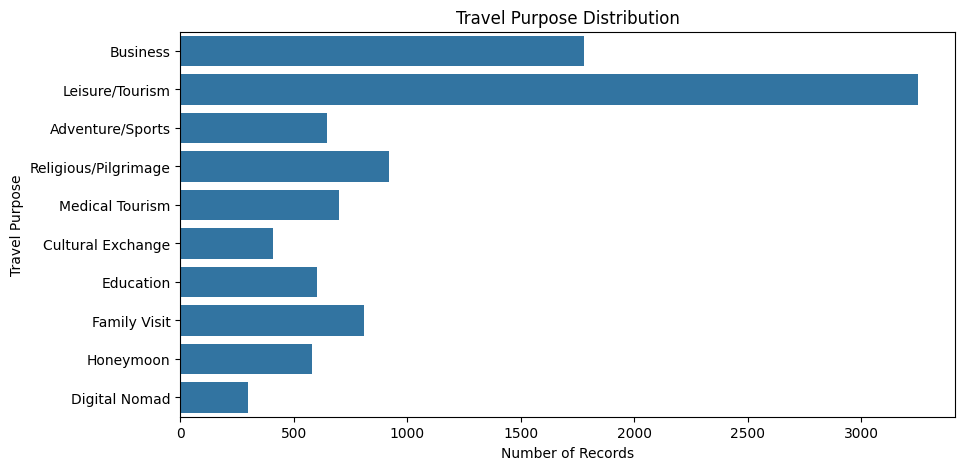

In [ ]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    y="travel_purpose"
)

plt.title("Travel Purpose Distribution")
plt.xlabel("Number of Records")
plt.ylabel("Travel Purpose")
plt.show()

This chart compares the number of records for each travel purpose. Leisure/Tourism is the most common travel purpose in the dataset.

### Visualization 3: Top 10 destination countries
3.3 Top 10 Destination Countries

This chart displays the ten destination countries with the highest number of tourism records.


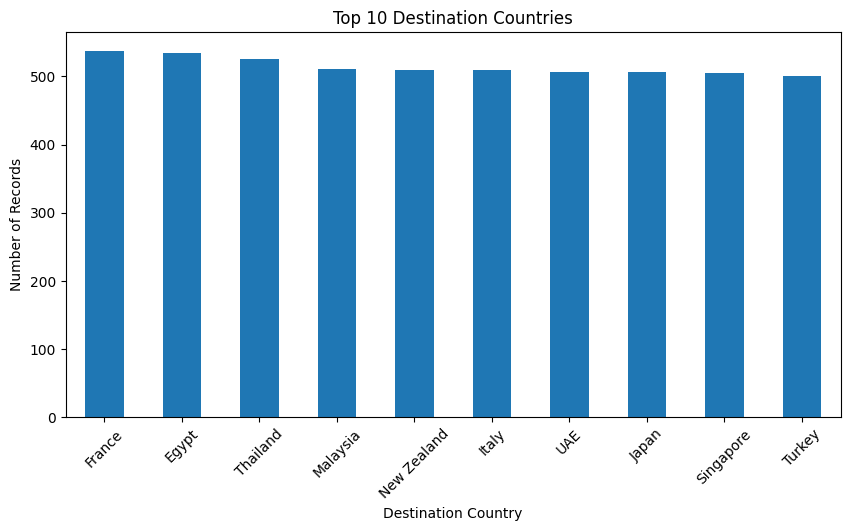

In [ ]:
top_destinations = (
    df["destination_country"]
    .value_counts()
    .head(10)
)

top_destinations.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Top 10 Destination Countries")
plt.xlabel("Destination Country")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.show()

This chart identifies the ten most common destination countries in the dataset. It helps us understand which destinations have more records.

### Visualization 4: Total-spending distribution
3.4 Distribution of Total Trip Spending

A histogram is used to understand how total trip spending is distributed.


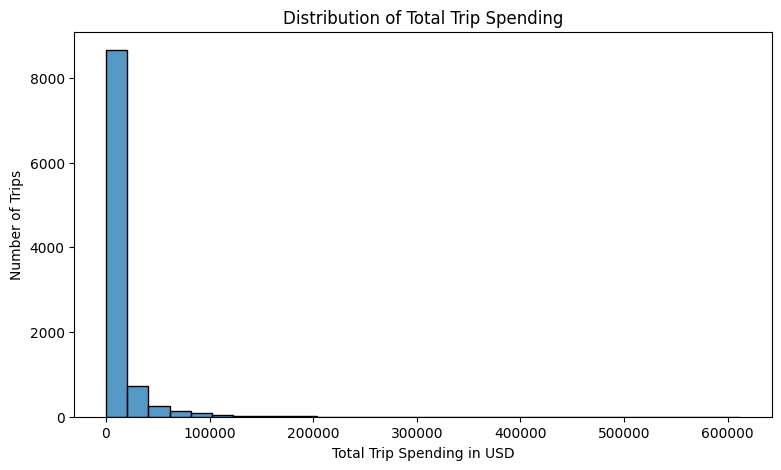

In [ ]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="total_trip_spend_usd",
    bins=30
)

plt.title("Distribution of Total Trip Spending")
plt.xlabel("Total Trip Spending in USD")
plt.ylabel("Number of Trips")
plt.show()

This histogram shows the common spending range and the number of low- and high-spending trips. It also helps identify unusually expensive trips.

### Visualization 5: Traveler-type distribution
### 3.5  Travel distribution

This chart shows the number of records for each traveler type.


<Axes: xlabel='count', ylabel='traveler_type'>

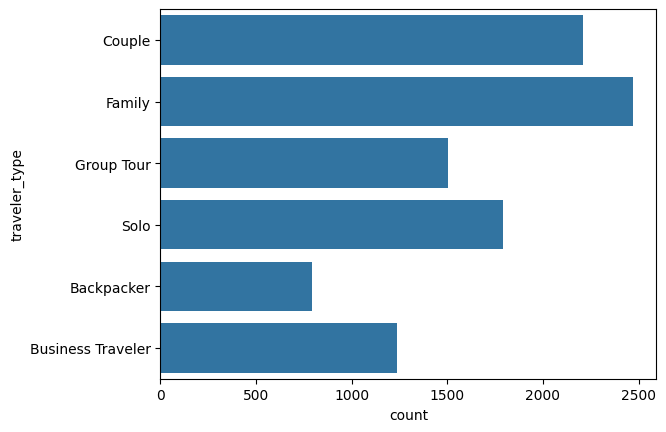

In [ ]:
sns.countplot(
    data=df,
    y="traveler_type"
)

**How the code works**

- `sns.countplot()` counts the records in each `traveler_type` category.
- The chart compares categories such as families, couples, solo travelers, and business travelers.

This chart is used to show which traveler groups have the largest and smallest representation in the dataset.

### Visualization 6: Total spending by traveler purpose
### 3.6 Spending by Traveler Type

This chart compares compares total trip spending across travel-purpose categories.

<Axes: xlabel='total_trip_spend_usd', ylabel='travel_purpose'>

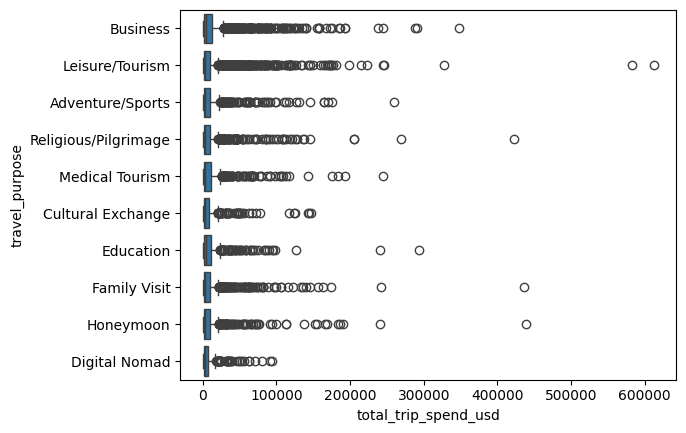

In [ ]:
sns.boxplot(
    data=df,
    x="total_trip_spend_usd",
    y="travel_purpose"
)

**How the code works**

- `sns.boxplot()` groups total spending by travel purpose.
- The line inside each box represents the median, and the box shows the spread of the middle values.

This chart is used to allow spending levels and variation to be compared across different travel-purpose groups.

## Visualization 7: Total spending by traveler type
###3.7 Spending by traveler type

This chart compares average total trip spending across traveler types.

<Axes: xlabel='total_trip_spend_usd', ylabel='traveler_type'>

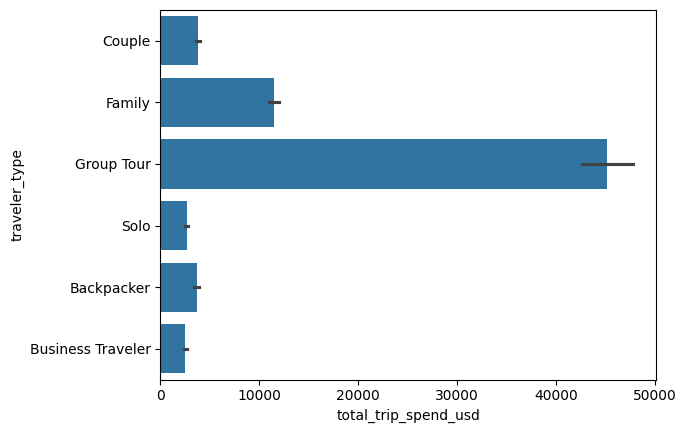

In [ ]:
sns.barplot(
    data=df,
    x="total_trip_spend_usd",
    y="traveler_type"
)

**How the code works**

- `sns.barplot()` groups records by traveler type.
- Seaborn calculates the average `total_trip_spend_usd` for every traveler group and displays it as a bar.

This chart is used to help compare the average total trip value of families, couples, solo travelers, and other traveler groups.

## Visualization 8: Trip duration and total spending
###3.8 Total trip spend

This scatter plot checks the relationship between trip duration and total spending.

<Axes: xlabel='duration_nights', ylabel='total_trip_spend_usd'>

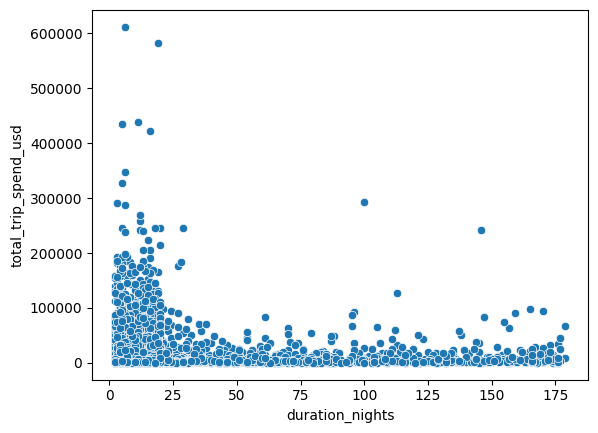

In [ ]:
sns.scatterplot(
    data=df,
    x="duration_nights",
    y="total_trip_spend_usd"
)

**How the code works**

- `sns.scatterplot()` places trip duration on the horizontal axis and total spending on the vertical axis.
- Each point represents one tourism record.

This chart is used to helps check whether longer trips generally have higher or lower total spending.

## Visualization 9: Budget by booking channel
###3.9 Budget by book channel

This chart compares average budget per person across booking channels.

<Axes: xlabel='budget_per_person_usd', ylabel='booking_channel'>

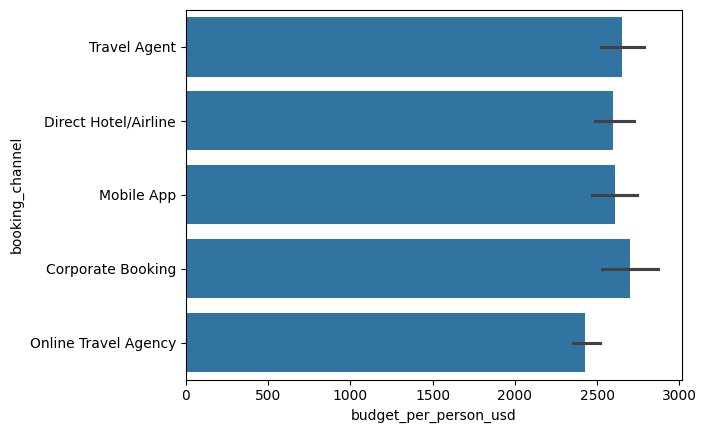

In [ ]:
sns.barplot(
    data=df,
    x="budget_per_person_usd",
    y="booking_channel"
)

**How the code works**

- `sns.barplot()` groups the records by booking channel.
- It calculates and displays the average budget per person for each channel.

This chart is used to help compare the planned budgets of customers using travel agents, mobile apps, online agencies, and other channels.

## Visualization 10: Rating by accommodation type
###3.10 Rating

This chart compares average trip rating across accommodation types.

<Axes: xlabel='trip_rating', ylabel='accommodation_type'>

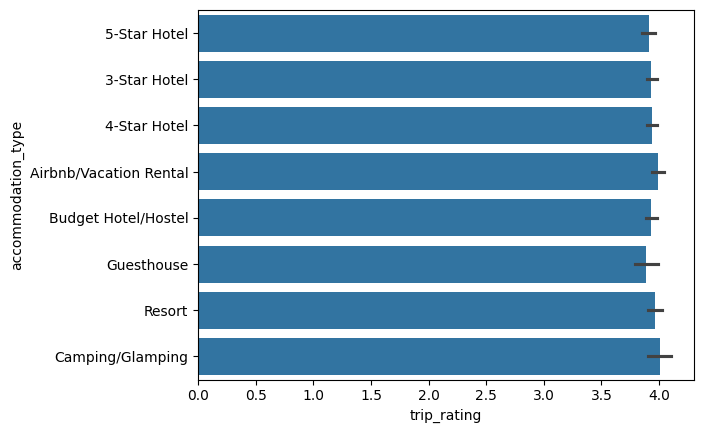

In [ ]:
sns.barplot(
    data=df,
    x="trip_rating",
    y="accommodation_type"
)

**How the code works**

- `sns.barplot()` groups records by accommodation type.
- It calculates the average trip rating for each accommodation category.

This chart is used to help compare the ratings associated with hotels, resorts, hostels, rentals, and other accommodation types.

## Visualization 11: Carbon footprint by transport mode
###3.11 Transport info

This chart compares average carbon footprint across transport modes.

<Axes: xlabel='carbon_footprint_kg_co2', ylabel='transport_mode'>

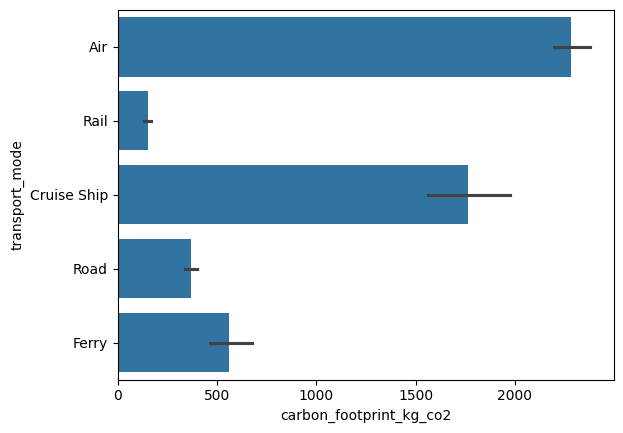

In [ ]:
sns.barplot(
    data=df,
    x="carbon_footprint_kg_co2",
    y="transport_mode"
)

**How the code works**

- `sns.barplot()` groups the records by transport mode.
- It calculates the average carbon footprint for each mode of transport.

This chart is used to provide a sustainability comparison between air, road, rail, ferry, and cruise travel.

## Visualization 12: Monthly average trip spending
###3.12 Avg spending per month

This line chart shows how average total trip spending changes across the months.

In [ ]:
monthly_spending = df.groupby(
    "month"
)["total_trip_spend_usd"].mean()

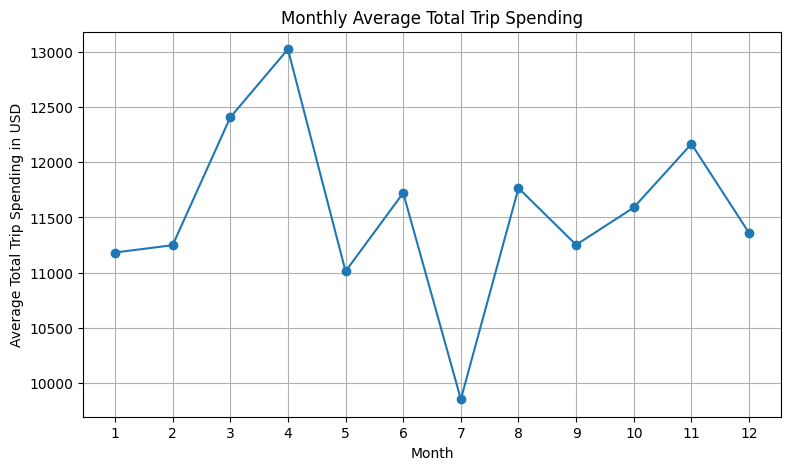

In [ ]:
import matplotlib.pyplot as plt

monthly_spending = (
    df.groupby("month")["total_trip_spend_usd"]
    .mean()
    .sort_index()
)

plt.figure(figsize=(9, 5))

plt.plot(
    monthly_spending.index,
    monthly_spending.values,
    marker="o"
)

plt.title("Monthly Average Total Trip Spending")
plt.xlabel("Month")
plt.ylabel("Average Total Trip Spending in USD")
plt.xticks(range(1, 13))
plt.grid(True)

plt.show()

**How the code works**

- `groupby("month")` places records from the same month together.
- `mean()` calculates average total spending for every month.
- A line chart connects the monthly averages in order.

This chart is used to help identify monthly changes and possible seasonal patterns in trip spending.

## Visualization 13: Duration, spending, and travel purpose
###3.13 Total trip spend info

This chart studies trip duration, total spending, and travel purpose together.

<Axes: xlabel='duration_nights', ylabel='total_trip_spend_usd'>

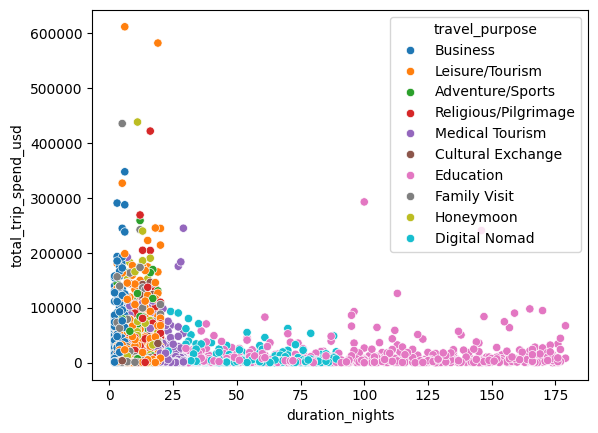

In [ ]:
sns.scatterplot(
    data=df,
    x="duration_nights",
    y="total_trip_spend_usd",
    hue="travel_purpose"
)

**How the code works**

- Duration is shown on the horizontal axis and total spending on the vertical axis.
- `hue="travel_purpose"` gives every travel purpose a different color.

It is a multivariate chart because it compares duration, spending, and travel purpose at the same time.

## Visualization 14: Correlation heatmap
###3.14 visual grid info

The heatmap compares relationships between several numerical variables.

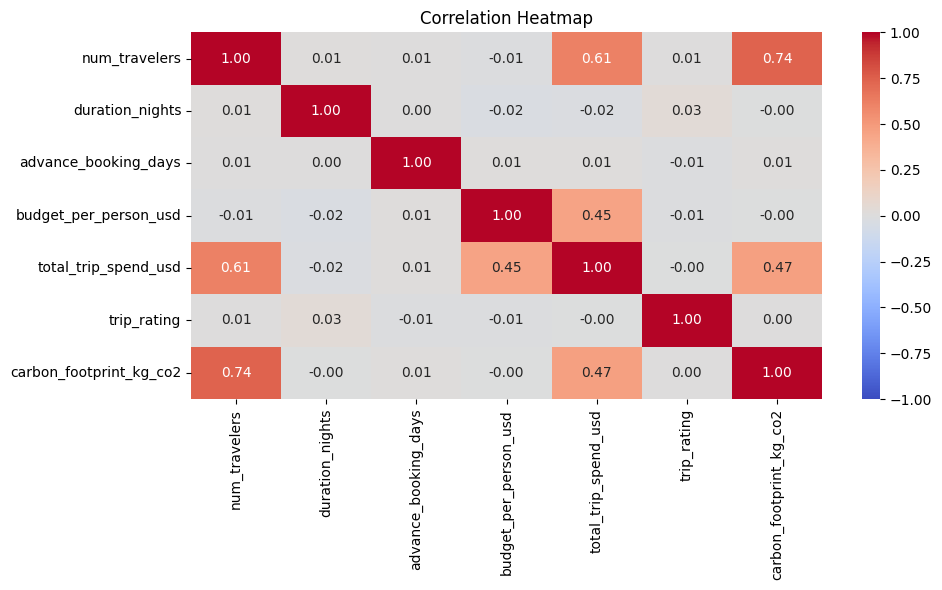

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Use this line only if df has not already been created
# df = pd.read_csv("global_tourism_travel_trends.csv")

selected_columns = [
    "num_travelers",
    "duration_nights",
    "advance_booking_days",
    "budget_per_person_usd",
    "total_trip_spend_usd",
    "trip_rating",
    "carbon_footprint_kg_co2"
]

# Select the numerical columns
numeric_data = df[selected_columns].copy()

# Make sure the values are treated as numbers
for column in selected_columns:
    numeric_data[column] = pd.to_numeric(
        numeric_data[column],
        errors="coerce"
    )

# Calculate correlations
correlation = numeric_data.corr()

# Create the heatmap
plt.figure(figsize=(10, 6))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

**How the code works**

- A list selects the important numerical columns.
- `.corr()` calculates the correlation between every pair of selected columns.
- `sns.heatmap()` displays the results using numbers and colors.

This chart is used allow several numerical relationships to be studied together. Values near 1 or -1 show stronger linear relationships, while values near 0 show weaker relationships.

### Overall explanation:
I used different chart types because each chart answers a different question. Count plots were used for category counts, bar charts were used to compare averages, a histogram was used to study spending distribution, and scatter plots were used to examine numerical relationships. A line chart was used for monthly analysis, while the heatmap was used to compare several numerical variables together. Each chart includes a title and axis labels so that the result is easy to understand.

###**Task 4: Documentation and Insights**

This section documents the dataset and turns the visual analysis into findings that can be checked and explained.

1. Dataset and analysis scope:

The analysis uses only the supplied global_tourism_travel_trends.csv file. It contains trip records, with fields describing when and where a trip occurred, its purpose, traveler group, duration, booking and accommodation choices, spending, rating, and estimated carbon footprint.

Each row is treated as one trip record. Spending and carbon footprint fields are analyzed as the dataset provides them; they are not assumed to be per-person measures.

2. Data-quality checks:

These checks report the dataset size, duplicate rows, and missing values. The original data is kept intact. Missing values are reported rather than silently replaced or deleting whole trip records.


The dataset has 10,000 rows and 33 columns, with no fully duplicated rows. Missing entries occur in language_barrier, health_safety_compliance, and social_media_shared. The numerical columns used in the charts and findings are complete, so those calculations can use all 10,000 trip records.

###Insight 1 — Leisure/Tourism is the largest travel-purpose group

Leisure/Tourism appears in 3,251 of the 10,000 trip records, or 32.51%. This is the largest travel-purpose category in the supplied dataset. Digital Nomad is the smallest category, with 297 records, or 2.97%.

This finding tells us what kinds of trips are most common in these records. It also means that a general result from the dataset may be influenced more by leisure trips than by less common types of travel. It would be incorrect to say that 32.51% of all tourism worldwide is leisure travel, because this dataset has not been shown to represent every traveler.


### Key insight 2: Total trip spending is unevenly distributed

The average total trip spending is $11,549.69, & median is $3,721.87. The largest recorded total is $612,141.57, & 157 trips have a total above $100,000.

The average and median answer different questions. The average includes the effect of every value, including unusually expensive trips. The median is the middle value after the trips are arranged by spending. Here the average is much higher than the median, which indicates that a small number of high-cost trips pull the average upward. Therefore, the median gives a clearer picture of a typical trip record. Expensive values should be reviewed, but we cannot assume they are mistakes simply because they are large.

### Key insight 3: Group tours have high total spending, but they also have larger groups

The average **total trip spending** for Group Tour records is $45,223.39.

The same records average 18.25 travelers per trip. In comparison & Solo trip records average $2,647.99 in total trip spending and have one traveler.

At first glance, the group-tour bar looks much higher than the solo-traveler bar. However, this chart compares totals for whole trips, not the amount paid by each person. A group tour contains many more travelers, so its larger total should not be presented as evidence that each group-tour traveler spends more than a solo traveler. A separate per-person comparison would be needed for that question.


## Key insight 4: Monthly average spending varies

April has the highest average total trip spending, at $13,026.58.

July has the lowest average, at $9,850.87 & April's average is approximately 32.24% higher than July's in the supplied data.

This comparison suggests that the records are not identical across months. It could be useful for thinking about when high-value trips occur, but the chart alone cannot tell us why. The travelers, destinations, group sizes, or a few expensive trips may differ between months. We should describe this as a monthly difference in the dataset, not as proof that April makes people spend more.

## Key insight 5: Air records have a higher average recorded carbon footprint than rail records

The average recorded carbon footprint is 2,282.05 kg CO₂ for trips in the Air category and 149.99 kg CO₂ for trips in the Rail category. The air average is approximately 15.21 times the rail average in these records.

This is an important sustainability observation, but it needs careful wording. The air and rail groups may contain trips of different distances and group sizes. Their averages are not a comparison of two otherwise identical journeys. The recorded footprint is also treated as a trip-level value here, not a per-traveler value. The result identifies a topic for further investigation; it does not isolate the effect of transport mode on its own.

## Key insight 6: Most trip ratings are positive

The average trip rating is 3.94 out of 5. A total of 75.06% of the trip records have a rating of 4 or 5. This indicates that high ratings are common in the supplied data.

However, an overall rating summarizes a whole experience. It does not tell us whether accommodation, transportation, safety, price, or another factor was responsible. Comparing the rating with one other column may be useful for exploring patterns, but it would not by itself prove what caused satisfaction.


## Overall explanation:

Together, the findings show that Leisure/Tourism is the largest purpose group, trip spending includes a small number of very high values, group trips need to be interpreted differently from individual trips, monthly spending averages vary, the recorded footprint differs substantially by transport category, and most trips receive high ratings. These results are more meaningful when the units of measurement and the differences between groups are explained alongside the numbers.

## Recommendations and next steps

Based on the analysis, the following recommendations can be made:

1. Use both mean and median for spending analysis
The spending data is highly skewed  due to a few very high values. Relying only on the mean can give a distorted picture, so using the median alongside it provides a more realistic understanding of typical spending.
   
2. Analyze spending on a per-person basis
Since the dataset recors total trip spending, group size has a strong influence on results. Converting spending into per-person values will allow for more accurate comparisons across different traveler types.
    
3. Encourage sustainable travel options
Air travel contributes significantly more to carbon emissions compared to other modes like ral or bus. Promting eco-friendly transport options can help educe the environmental impact of tourism.
    
4. Consider seasonal trends in planning
The analysis shows that travel spending varies across different months.Business and policymakers should align their strategies with peak and off-peak seasons to optimize performance.
    
5. Handle missing data carefully
  Some variables contain missing values, which may affect the reliability of insights. Proper data cleaning and handling techniques should be applied before drawing conclusions.


**Next Steps**

To further improve and extend this project, the following steps are recommended:

1. Use larger and more realistic datasets
Incoporating real-world and more diverse datasets will make the analysis more accurate and widely applicable.
    
2. Perform deeper segmentation analysis
Analyzing data based on traveler demographics, regions, or behavior can provide more detailed and meaningful insights.
    
3. Apply predictive techniques
Machine learning models can be used to forecast future travel trends, spending patterns, and environmental impact.
    
4. Improve data quality and feature engineering
Handling missing values,removing outliers, and creating new relevant variables can enhance the quality of analysis.
    
5. Compare trends across regions and time periods
Studying how travel patterns differ across countries or years can help identify broader global trends as well as local variations.

# **Final Conclusion**

This project explored the Global Tourism and Travel Trends dataset using Exploratory Data Analysis (EDA) to uncover meaningful patterns in travel behavior, spending, and environmental impact.

The analysis shows that leisure travel is the most dominant purpose, meaning the dataset is largely driven by tourism-related activities. It was also observed that spending is highly uneven (right-skewed), where a small number of trips contribute to very high costs. Because of this, the median provides a more reliable measure than the mean when understanding typical spending.

Another key finding is that group tours have the highest total spending, mainly due to the larger number of travelers per trip rather than higher individual expenses. The study also highlights clear seasonal trends, with spending varying across months, indicating that travel demand changes over time.

From an environmental perspective, the analysis shows that transport mode plays a critical role, with air travel contributing significantly higher carbon emissions compared to other options like rail. This emphasizes the growing importance of sustainable travel choices.

However, the analysis has some limitations. The dataset is trip-based rather than per-person, includes missing values, and the results represent correlations rather than cause-and-effect relationships.

In conclusion, this project demonstrates how EDA can be effectively used to generate data-driven insights in the tourism sector. While the findings provide valuable guidance for decision-making, they should be interpreted carefully, keeping the dataset’s limitations in mind.